# Import Library

In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

In [52]:
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
warnings.filterwarnings('ignore')

# Load Dataset

In [53]:
df_master = pd.read_excel('/kaggle/input/datasets/adenyuy/ntg-dataset/master_aset_enriched (2).xlsx')
df_komplain = pd.read_excel('/kaggle/input/datasets/adenyuy/ntg-dataset/aset_komplain_enriched (2).xlsx')
df_frekuensi = pd.read_excel('/kaggle/input/datasets/adenyuy/ntg-dataset/rencana_kegiatan_frekuensi_enriched (2).xlsx')
df_penggantian = pd.read_excel('/kaggle/input/datasets/adenyuy/ntg-dataset/riwayat_penggantian_aset (1).xlsx')

In [54]:
df_master.head()

,ID,Nama,Merek,Model,Kategori,Sub Kategori,Tipe,Tanggal Instalasi,Lokasi Gedung,Lokasi Lantai,Lokasi Zona,Tingkat Kekritisan,Status
0,28,MIT-E0IF-0028,Mitsubishi,MSY-GN-792,Mechanical,Tata Udara,AC Split,21-04-2024,Gedung B,10,Barat,Critical,Aktif
1,7968,MAS-SAHX-7968,Maspion,TYP-7873,Ventilasi Sistem,Sistem Sirkulasi Udara,Kipas Angin,21-06-2018,Gedung Servis,3,Timur,Minor,Aktif
2,30,GRE-FPKH-0030,Gree,SER-2674,Mechanical,Tata Udara,AC Split,14-01-2017,Gedung Parkir,1,Timur,Minor,Aktif
3,31,GRE-BQE7-0031,Gree,MDL-5803,Mechanical,Tata Udara,AC Split,18-01-2023,Gedung Utama,19,Selatan,Major,Aktif
4,32,PAN-1945-0032,Panasonic,CS-PC-384,Mechanical,Tata Udara,AC Split,31-01-2021,Gedung Utama,6,Timur,Major,Aktif


In [55]:
df_master.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49679 entries, 0 to 49678
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   ID                  49679 non-null  int64 
 1   Nama                49679 non-null  object
 2   Merek               49679 non-null  object
 3   Model               49679 non-null  object
 4   Kategori            49679 non-null  object
 5   Sub Kategori        49679 non-null  object
 6   Tipe                49679 non-null  object
 7   Tanggal Instalasi   49679 non-null  object
 8   Lokasi Gedung       49679 non-null  object
 9   Lokasi Lantai       49679 non-null  int64 
 10  Lokasi Zona         49679 non-null  object
 11  Tingkat Kekritisan  49679 non-null  object
 12  Status              49679 non-null  object
dtypes: int64(2), object(11)
memory usage: 4.9+ MB


In [56]:
df_komplain.head()

,ID Aset,Nama Aset,Kategori,Sub Kategori,Tipe,Tanggal Perencanaan,Tanggal Pengerjaan,Tanggal Selesai,Jenis Kerusakan,Severity,Penyebab,Biaya Perbaikan,Spare Part Digunakan,Teknisi Pelaksana
0,14760,LG-0PVY-14760,Mechanical,Tata Udara,AC Cassette,01-01-2023,08-01-2023,09-01-2023,Retak/pecah,Fatal,Kelembaban tinggi,18771000,"Kompresor, Thermostat","Budi Santoso, Teguh Prabowo"
1,30028,BOS-7XLT-30028,Security Sistem,Sistem Pengawasan,Kamera CCTV,01-01-2023,02-01-2023,02-01-2023,Overheat,Ringan,Human error,356000,"Hard disk, Konektor","Nanda Pratama, Budi Santoso"
2,48538,PAN-GYNA-48538,Electrical,Panel Distribusi,Panel UPS,01-01-2023,02-01-2023,07-01-2023,Remote tidak berfungsi,Sedang,Overload,1610000,Saklar,"Kukuh Firmansyah, Lukman Hakim, Oscar Hidayat"
3,41836,DAI-5FQT-41836,Mechanical,Tata Udara,AC Split,01-01-2023,08-01-2023,08-01-2023,Overheat,Ringan,Kurang perawatan,122000,Kapasitor,Rizal Mahendra
4,49297,KIC-FZS6-49297,Security Sistem,Sistem Keamanan,Kick Bar,01-01-2023,01-01-2023,03-01-2023,Getaran berlebihan,Sedang,Tegangan tidak stabil,1760000,"Hard disk, Adaptor, Lensa kamera",Hendra Saputra


In [57]:
df_komplain.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46409 entries, 0 to 46408
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   ID Aset               46409 non-null  int64 
 1   Nama Aset             46409 non-null  object
 2   Kategori              46409 non-null  object
 3   Sub Kategori          46409 non-null  object
 4   Tipe                  46409 non-null  object
 5   Tanggal Perencanaan   46409 non-null  object
 6   Tanggal Pengerjaan    46409 non-null  object
 7   Tanggal Selesai       46409 non-null  object
 8   Jenis Kerusakan       46409 non-null  object
 9   Severity              46409 non-null  object
 10  Penyebab              46409 non-null  object
 11  Biaya Perbaikan       46409 non-null  int64 
 12  Spare Part Digunakan  46409 non-null  object
 13  Teknisi Pelaksana     46409 non-null  object
dtypes: int64(2), object(12)
memory usage: 5.0+ MB


In [58]:
df_frekuensi.head()

,Kategori,Sub Kategori,Tipe,Frekuensi
0,Mechanical,Tata Udara,AC Cassette,Harian
1,Mechanical,Tata Udara,AC Split,Harian
2,Mechanical,Tata Udara,AC Split,Harian
3,Mechanical,Tata Udara,AC Split,Harian
4,Mechanical,Tata Udara,AC Split,Harian


In [59]:
df_frekuensi.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180847 entries, 0 to 180846
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   Kategori      180847 non-null  object
 1   Sub Kategori  180847 non-null  object
 2   Tipe          180847 non-null  object
 3   Frekuensi     180847 non-null  object
dtypes: object(4)
memory usage: 5.5+ MB


In [60]:
df_penggantian.head()

,ID Aset Lama,Nama Aset Lama,Kategori,Tipe,ID Aset Baru,Tanggal Penggantian,Alasan Penggantian,Biaya Penggantian
0,653,MON-B7QM-0653,Sistem Telekomunikasi Gedung,Monitor/Layar,93440,01-01-2020,Tidak ada spare part,62190000
1,16743,CON-HE6U-16743,Electrical,Control Panel Penerangan,79248,01-01-2020,Usia pakai habis,85490000
2,17417,INA-4Y65-17417,Plumbing,Wastafel,90218,01-01-2021,Efisiensi energi,94470000
3,57200,DAI-WCF6-57200,Mechanical,AC Split,53728,01-01-2024,Standar keamanan baru,34690000
4,33187,PLA-F1ZF-33187,Arsitektur,Plafon,71321,01-01-2025,Tidak ada spare part,12400000


In [61]:
df_penggantian.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2058 entries, 0 to 2057
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   ID Aset Lama         2058 non-null   int64 
 1   Nama Aset Lama       2058 non-null   object
 2   Kategori             2058 non-null   object
 3   Tipe                 2058 non-null   object
 4   ID Aset Baru         2058 non-null   int64 
 5   Tanggal Penggantian  2058 non-null   object
 6   Alasan Penggantian   2058 non-null   object
 7   Biaya Penggantian    2058 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 128.8+ KB


# EDA - MASTER DATASET

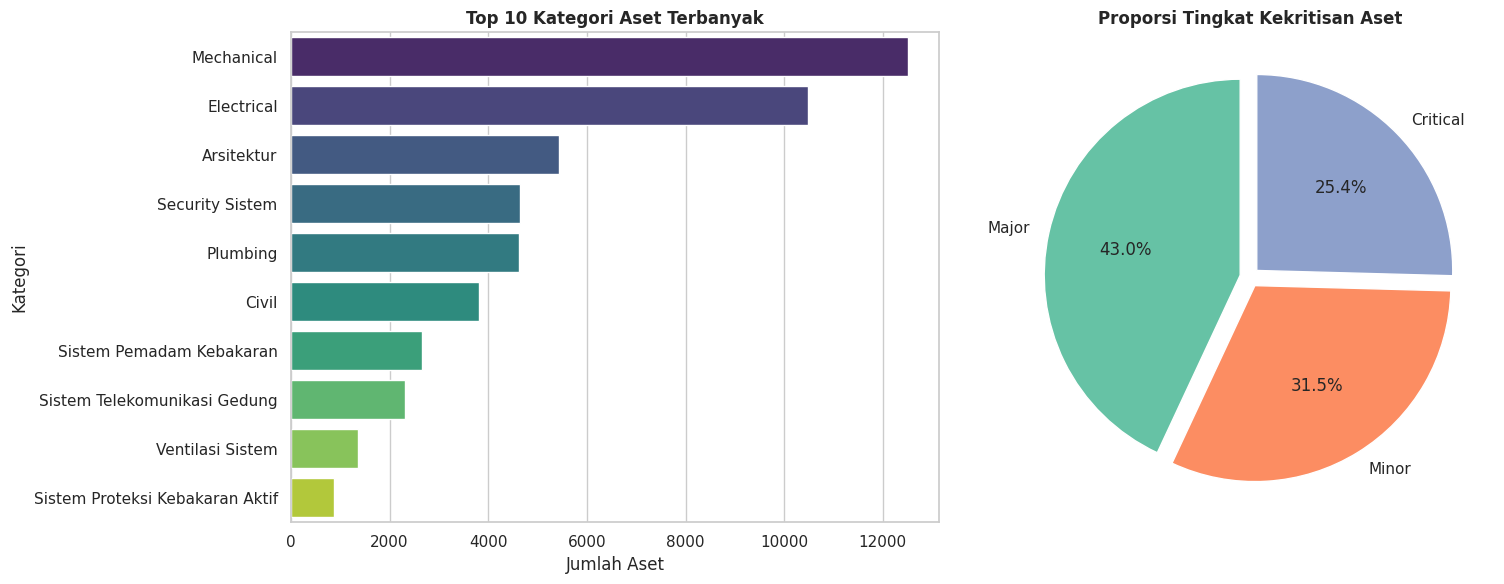

In [62]:
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

top_kategori = df_master['Kategori'].value_counts().nlargest(10)
sns.barplot(x=top_kategori.values, y=top_kategori.index, palette='viridis', ax=ax[0])
ax[0].set_title('Top 10 Kategori Aset Terbanyak', fontweight='bold')
ax[0].set_xlabel('Jumlah Aset')
ax[0].set_ylabel('Kategori')

kekritisan_count = df_master['Tingkat Kekritisan'].value_counts()
ax[1].pie(kekritisan_count.values, labels=kekritisan_count.index, autopct='%1.1f%%', 
          colors=sns.color_palette('Set2'), startangle=90, explode=[0.05]*len(kekritisan_count))
ax[1].set_title('Proporsi Tingkat Kekritisan Aset', fontweight='bold')

plt.tight_layout()
plt.show()

# EDA - KOMPLAIN DATASET

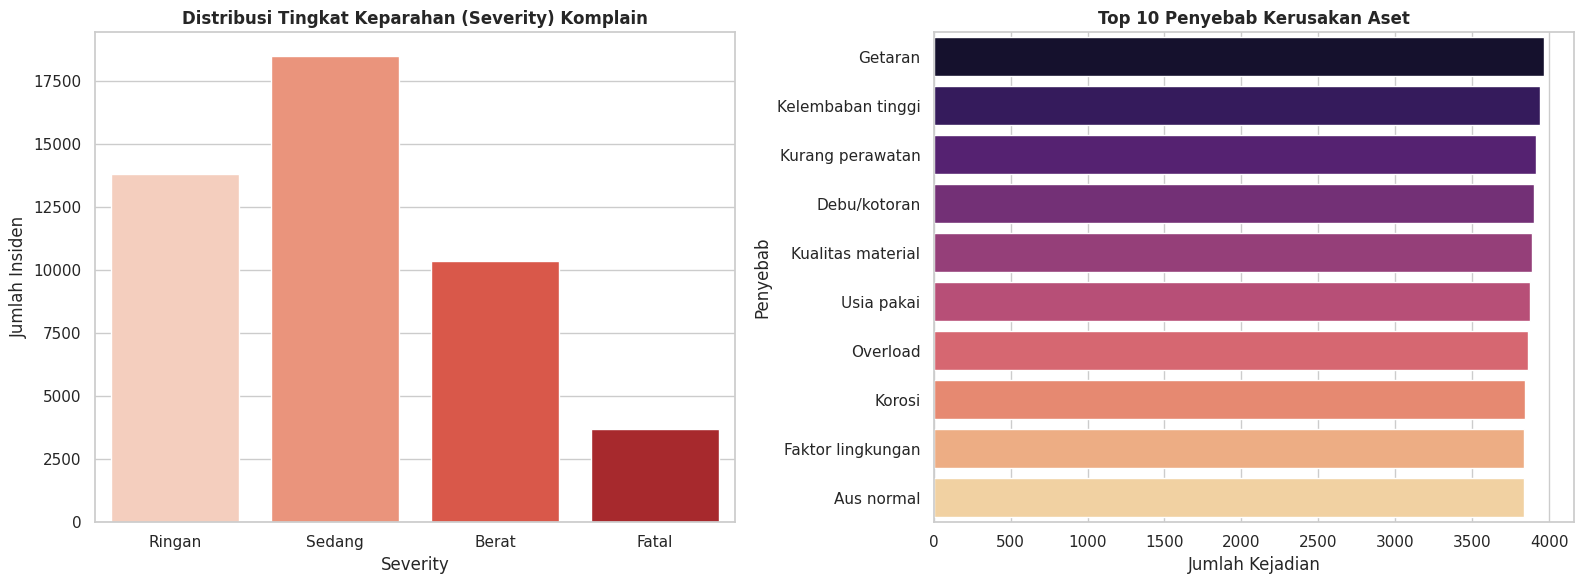

In [63]:
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

severity_order = ['Ringan', 'Sedang', 'Berat', 'Fatal']
sns.countplot(data=df_komplain, x='Severity', order=severity_order, palette='Reds', ax=ax[0])
ax[0].set_title('Distribusi Tingkat Keparahan (Severity) Komplain', fontweight='bold')
ax[0].set_xlabel('Severity')
ax[0].set_ylabel('Jumlah Insiden')

top_penyebab = df_komplain['Penyebab'].value_counts().nlargest(10)
sns.barplot(x=top_penyebab.values, y=top_penyebab.index, palette='magma', ax=ax[1])
ax[1].set_title('Top 10 Penyebab Kerusakan Aset', fontweight='bold')
ax[1].set_xlabel('Jumlah Kejadian')
ax[1].set_ylabel('Penyebab')

plt.tight_layout()
plt.show()

# EDA - FREKUENSI DATASET

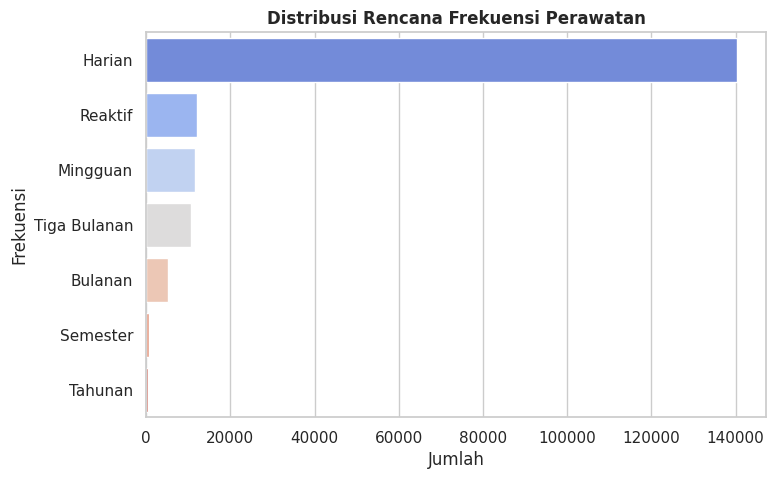

In [64]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df_frekuensi, y='Frekuensi', order=df_frekuensi['Frekuensi'].value_counts().index, palette='coolwarm')

plt.title('Distribusi Rencana Frekuensi Perawatan', fontweight='bold')
plt.xlabel('Jumlah')
plt.ylabel('Frekuensi')
plt.show()

# EDA - PENGGANTIAN DATASET

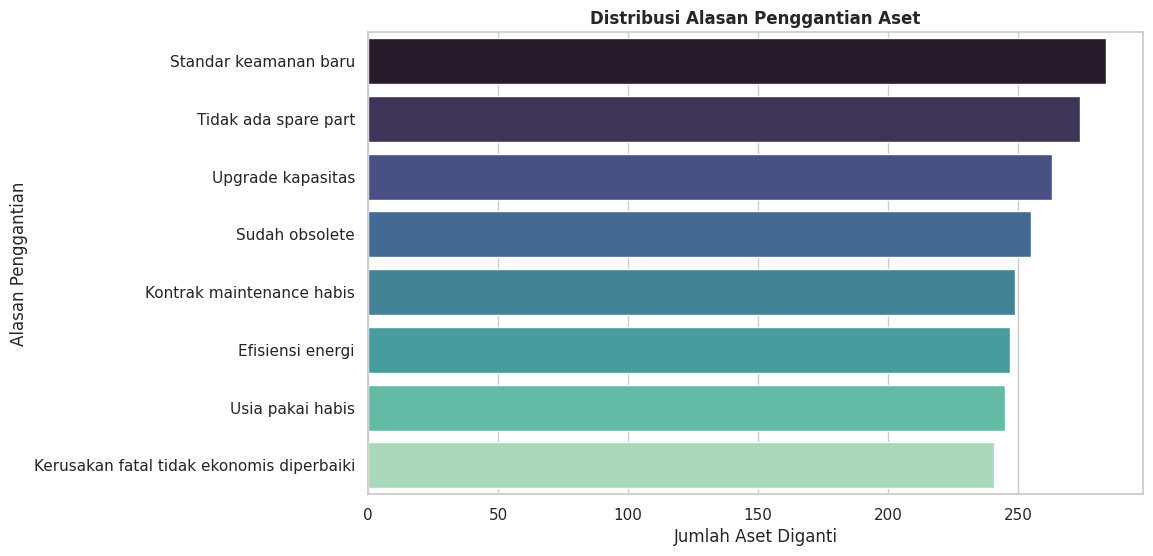

In [65]:
plt.figure(figsize=(10, 6))

alasan_count = df_penggantian['Alasan Penggantian'].value_counts()
sns.barplot(x=alasan_count.values, y=alasan_count.index, palette='mako')

plt.title('Distribusi Alasan Penggantian Aset', fontweight='bold')
plt.xlabel('Jumlah Aset Diganti')
plt.ylabel('Alasan Penggantian')
plt.show()

# PREPROCESSING

In [66]:
cols_master = ['ID', 'Kategori', 'Sub Kategori', 'Tipe', 'Tanggal Instalasi', 'Tingkat Kekritisan']
df_master_clean = df_master[cols_master].copy()

In [67]:
df_master_clean['Tanggal Instalasi'] = pd.to_datetime(df_master_clean['Tanggal Instalasi'], format='%d-%m-%Y', errors='coerce')

In [68]:
df_master_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49679 entries, 0 to 49678
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   ID                  49679 non-null  int64         
 1   Kategori            49679 non-null  object        
 2   Sub Kategori        49679 non-null  object        
 3   Tipe                49679 non-null  object        
 4   Tanggal Instalasi   49679 non-null  datetime64[ns]
 5   Tingkat Kekritisan  49679 non-null  object        
dtypes: datetime64[ns](1), int64(1), object(4)
memory usage: 2.3+ MB


In [69]:
cols_komplain = ['ID Aset', 'Biaya Perbaikan', 'Jenis Kerusakan', 'Severity', 'Tanggal Perencanaan', 'Tanggal Pengerjaan', 'Tanggal Selesai']
df_komplain_clean = df_komplain[cols_komplain].copy()

In [70]:
kolom_waktu_komplain = ['Tanggal Perencanaan', 'Tanggal Pengerjaan', 'Tanggal Selesai']
for col in kolom_waktu_komplain:
    df_komplain_clean[col] = pd.to_datetime(df_komplain_clean[col], format='%d-%m-%Y', errors='coerce')

df_komplain_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46409 entries, 0 to 46408
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   ID Aset              46409 non-null  int64         
 1   Biaya Perbaikan      46409 non-null  int64         
 2   Jenis Kerusakan      46409 non-null  object        
 3   Severity             46409 non-null  object        
 4   Tanggal Perencanaan  46409 non-null  datetime64[ns]
 5   Tanggal Pengerjaan   46409 non-null  datetime64[ns]
 6   Tanggal Selesai      46409 non-null  datetime64[ns]
dtypes: datetime64[ns](3), int64(2), object(2)
memory usage: 2.5+ MB


In [71]:
cols_penggantian = ['ID Aset Lama', 'Tanggal Penggantian', 'Biaya Penggantian', 'Tipe']
df_penggantian_clean = df_penggantian[cols_penggantian].copy()

In [72]:
df_penggantian_clean['Tanggal Penggantian'] = pd.to_datetime(df_penggantian_clean['Tanggal Penggantian'], format='%d-%m-%Y', errors='coerce')

In [73]:
df_penggantian_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2058 entries, 0 to 2057
Data columns (total 4 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   ID Aset Lama         2058 non-null   int64         
 1   Tanggal Penggantian  2058 non-null   datetime64[ns]
 2   Biaya Penggantian    2058 non-null   int64         
 3   Tipe                 2058 non-null   object        
dtypes: datetime64[ns](1), int64(2), object(1)
memory usage: 64.4+ KB


In [74]:
cols_frekuensi = ['Kategori', 'Sub Kategori', 'Tipe', 'Frekuensi']
df_frekuensi_clean = df_frekuensi[cols_frekuensi].copy()

In [75]:
df_frekuensi_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180847 entries, 0 to 180846
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   Kategori      180847 non-null  object
 1   Sub Kategori  180847 non-null  object
 2   Tipe          180847 non-null  object
 3   Frekuensi     180847 non-null  object
dtypes: object(4)
memory usage: 5.5+ MB


In [76]:
df_frekuensi_unik = df_frekuensi_clean.groupby(['Kategori', 'Sub Kategori', 'Tipe'])['Frekuensi'].agg(
    lambda x: x.mode()[0] if not x.mode().empty else x.iloc[0]
).reset_index()

df_frekuensi_unik.rename(columns={'Frekuensi': 'Target_Frekuensi'}, inplace=True)

df_frekuensi_unik.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Kategori          200 non-null    object
 1   Sub Kategori      200 non-null    object
 2   Tipe              200 non-null    object
 3   Target_Frekuensi  200 non-null    object
dtypes: object(4)
memory usage: 6.4+ KB


In [77]:
df_frekuensi_unik.head()

,Kategori,Sub Kategori,Tipe,Target_Frekuensi
0,Arsitektur,Exterior Gedung,Pagar Besi,Reaktif
1,Arsitektur,Exterior Gedung,Pintu Gerbang Besi,Reaktif
2,Arsitektur,Interior Gedung,Kursi,Reaktif
3,Arsitektur,Interior Gedung,Lemari/Loker,Reaktif
4,Arsitektur,Interior Gedung,Meja kerja,Reaktif


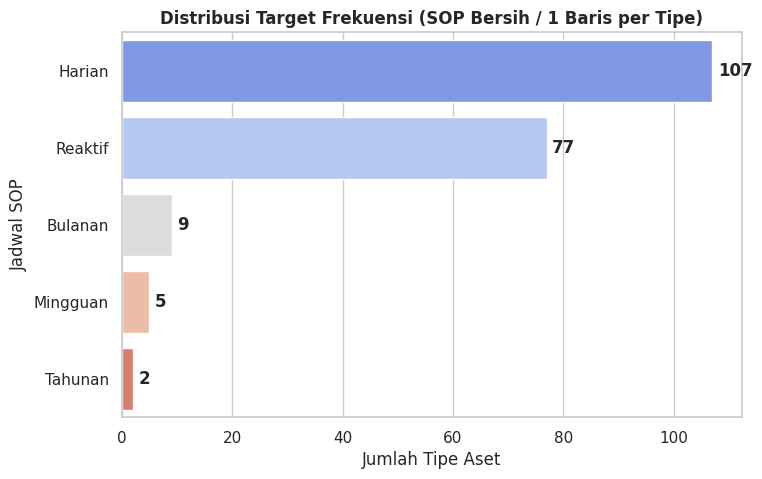

Target_Frekuensi
Harian      107
Reaktif      77
Bulanan       9
Mingguan      5
Tahunan       2
Name: count, dtype: int64

In [78]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.countplot(data=df_frekuensi_unik, y='Target_Frekuensi', 
              order=df_frekuensi_unik['Target_Frekuensi'].value_counts().index, 
              palette='coolwarm')

plt.title('Distribusi Target Frekuensi (SOP Bersih / 1 Baris per Tipe)', fontweight='bold')
plt.xlabel('Jumlah Tipe Aset')
plt.ylabel('Jadwal SOP')

for index, value in enumerate(df_frekuensi_unik['Target_Frekuensi'].value_counts()):
    plt.text(value + 1, index, str(value), va='center', fontweight='bold')

plt.show()

df_frekuensi_unik['Target_Frekuensi'].value_counts()

# FEATURE ENGINEERING

In [79]:
kritis_map = {'Minor': 1, 'Major': 2, 'Critical': 3}
df_master_clean['Kekritisan_Score'] = df_master_clean['Tingkat Kekritisan'].map(kritis_map).fillna(1)
df_master_clean.drop(columns=['Tingkat Kekritisan'], inplace=True) 

In [80]:
penggantian_agg = df_penggantian_clean.groupby('Tipe').agg(
    Avg_Biaya_Penggantian=('Biaya Penggantian', 'median')
).reset_index()

In [81]:
df_master_clean.head()

,ID,Kategori,Sub Kategori,Tipe,Tanggal Instalasi,Kekritisan_Score
0,28,Mechanical,Tata Udara,AC Split,2024-04-21,3
1,7968,Ventilasi Sistem,Sistem Sirkulasi Udara,Kipas Angin,2018-06-21,1
2,30,Mechanical,Tata Udara,AC Split,2017-01-14,1
3,31,Mechanical,Tata Udara,AC Split,2023-01-18,2
4,32,Mechanical,Tata Udara,AC Split,2021-01-31,2


In [82]:
df_penggantian_clean.head()

,ID Aset Lama,Tanggal Penggantian,Biaya Penggantian,Tipe
0,653,2020-01-01,62190000,Monitor/Layar
1,16743,2020-01-01,85490000,Control Panel Penerangan
2,17417,2021-01-01,94470000,Wastafel
3,57200,2024-01-01,34690000,AC Split
4,33187,2025-01-01,12400000,Plafon


In [83]:
df_komplain_clean['Maintenance_Delay'] = (df_komplain_clean['Tanggal Pengerjaan'] - df_komplain_clean['Tanggal Perencanaan']).dt.days.clip(lower=0)
df_komplain_clean['Downtime'] = (df_komplain_clean['Tanggal Selesai'] - df_komplain_clean['Tanggal Pengerjaan']).dt.days.clip(lower=0)

severity_map = {'Ringan': 1, 'Sedang': 2, 'Berat': 3, 'Fatal': 4}
df_komplain_clean['Severity_Score'] = df_komplain_clean['Severity'].map(severity_map)

In [84]:
komplain_agg = df_komplain_clean.groupby('ID Aset').agg(
    Avg_Maintenance_Delay=('Maintenance_Delay', 'mean'),
    Max_Maintenance_Delay=('Maintenance_Delay', 'max'),
    Total_Downtime=('Downtime', 'sum'),
    Avg_Downtime=('Downtime', 'mean'),
    Total_Biaya_Perbaikan=('Biaya Perbaikan', 'sum'),
    Failure_Frequency=('ID Aset', 'count'),
    Peak_Severity=('Severity_Score', 'max')
).reset_index()

komplain_agg.shape

(15871, 8)

In [85]:
df_komplain_clean.head()

,ID Aset,Biaya Perbaikan,Jenis Kerusakan,Severity,Tanggal Perencanaan,Tanggal Pengerjaan,Tanggal Selesai,Maintenance_Delay,Downtime,Severity_Score
0,14760,18771000,Retak/pecah,Fatal,2023-01-01,2023-01-08,2023-01-09,7,1,4
1,30028,356000,Overheat,Ringan,2023-01-01,2023-01-02,2023-01-02,1,0,1
2,48538,1610000,Remote tidak berfungsi,Sedang,2023-01-01,2023-01-02,2023-01-07,1,5,2
3,41836,122000,Overheat,Ringan,2023-01-01,2023-01-08,2023-01-08,7,0,1
4,49297,1760000,Getaran berlebihan,Sedang,2023-01-01,2023-01-01,2023-01-03,0,2,2


In [86]:
df_komplain_clean['Tanggal Selesai'].max()

Timestamp('2026-01-16 00:00:00')

In [87]:
df_penggantian_clean['Tanggal Penggantian'].max()

Timestamp('2025-12-30 00:00:00')

In [88]:
df_master_clean['Tanggal Instalasi'].max()

Timestamp('2024-12-31 00:00:00')

In [89]:
df_komplain_clean['Tanggal Perencanaan'].max()

Timestamp('2025-12-31 00:00:00')

In [90]:
df_komplain_clean['Tanggal Pengerjaan'].max()

Timestamp('2026-01-14 00:00:00')

In [91]:
df_master_clean.rename(columns={'ID': 'ID Aset'}, inplace=True)

abt = pd.merge(df_master_clean, komplain_agg, on='ID Aset', how='left')

kolom_perilaku = ['Avg_Maintenance_Delay', 'Max_Maintenance_Delay', 'Total_Downtime', 'Avg_Downtime', 'Total_Biaya_Perbaikan', 'Failure_Frequency', 'Peak_Severity']
for col in kolom_perilaku:
    if col in abt.columns:
        abt[col] = abt[col].fillna(0)

abt = pd.merge(abt, penggantian_agg, on='Tipe', how='left')

abt['Avg_Biaya_Penggantian'] = abt['Avg_Biaya_Penggantian'].fillna(abt['Total_Biaya_Perbaikan'] + 1)
abt['Cost_Risk_Ratio'] = abt['Total_Biaya_Perbaikan'] / abt['Avg_Biaya_Penggantian']

max_tgl_instalasi = abt['Tanggal Instalasi'].max()
max_tgl_komplain = df_komplain_clean['Tanggal Selesai'].max()
max_tgl_ganti = df_penggantian_clean['Tanggal Penggantian'].max()

tanggal_evaluasi = pd.Series([max_tgl_instalasi, max_tgl_komplain, max_tgl_ganti]).max() + pd.Timedelta(days=1)

abt['Umur_Aset_Hari'] = (tanggal_evaluasi - abt['Tanggal Instalasi']).dt.days

abt = pd.merge(abt, df_frekuensi_unik, on=['Kategori', 'Sub Kategori', 'Tipe'], how='left')
abt.dropna(subset=['Target_Frekuensi'], inplace=True)

abt.head()

,ID Aset,Kategori,Sub Kategori,Tipe,Tanggal Instalasi,Kekritisan_Score,Avg_Maintenance_Delay,Max_Maintenance_Delay,Total_Downtime,Avg_Downtime,Total_Biaya_Perbaikan,Failure_Frequency,Peak_Severity,Avg_Biaya_Penggantian,Cost_Risk_Ratio,Umur_Aset_Hari,Target_Frekuensi
0,28,Mechanical,Tata Udara,AC Split,2024-04-21,3,0.0,0.0,0.0,0.00,0.0,0.0,0.0,52615000.0,0.000000,636,Harian
1,7968,Ventilasi Sistem,Sistem Sirkulasi Udara,Kipas Angin,2018-06-21,1,1.0,1.0,0.0,0.00,1799000.0,1.0,2.0,1799001.0,0.999999,2767,Harian
2,30,Mechanical,Tata Udara,AC Split,2017-01-14,1,0.0,0.0,0.0,0.00,0.0,0.0,0.0,52615000.0,0.000000,3290,Harian
3,31,Mechanical,Tata Udara,AC Split,2023-01-18,2,4.5,14.0,1.0,0.25,22780000.0,4.0,4.0,52615000.0,0.432956,1095,Harian
4,32,Mechanical,Tata Udara,AC Split,2021-01-31,2,0.0,0.0,0.0,0.00,0.0,0.0,0.0,52615000.0,0.000000,1812,Harian


In [92]:
abt.info()

<class 'pandas.core.frame.DataFrame'>
Index: 48344 entries, 0 to 49678
Data columns (total 17 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   ID Aset                48344 non-null  int64         
 1   Kategori               48344 non-null  object        
 2   Sub Kategori           48344 non-null  object        
 3   Tipe                   48344 non-null  object        
 4   Tanggal Instalasi      48344 non-null  datetime64[ns]
 5   Kekritisan_Score       48344 non-null  int64         
 6   Avg_Maintenance_Delay  48344 non-null  float64       
 7   Max_Maintenance_Delay  48344 non-null  float64       
 8   Total_Downtime         48344 non-null  float64       
 9   Avg_Downtime           48344 non-null  float64       
 10  Total_Biaya_Perbaikan  48344 non-null  float64       
 11  Failure_Frequency      48344 non-null  float64       
 12  Peak_Severity          48344 non-null  float64       
 13  Avg_Bi

# EDA

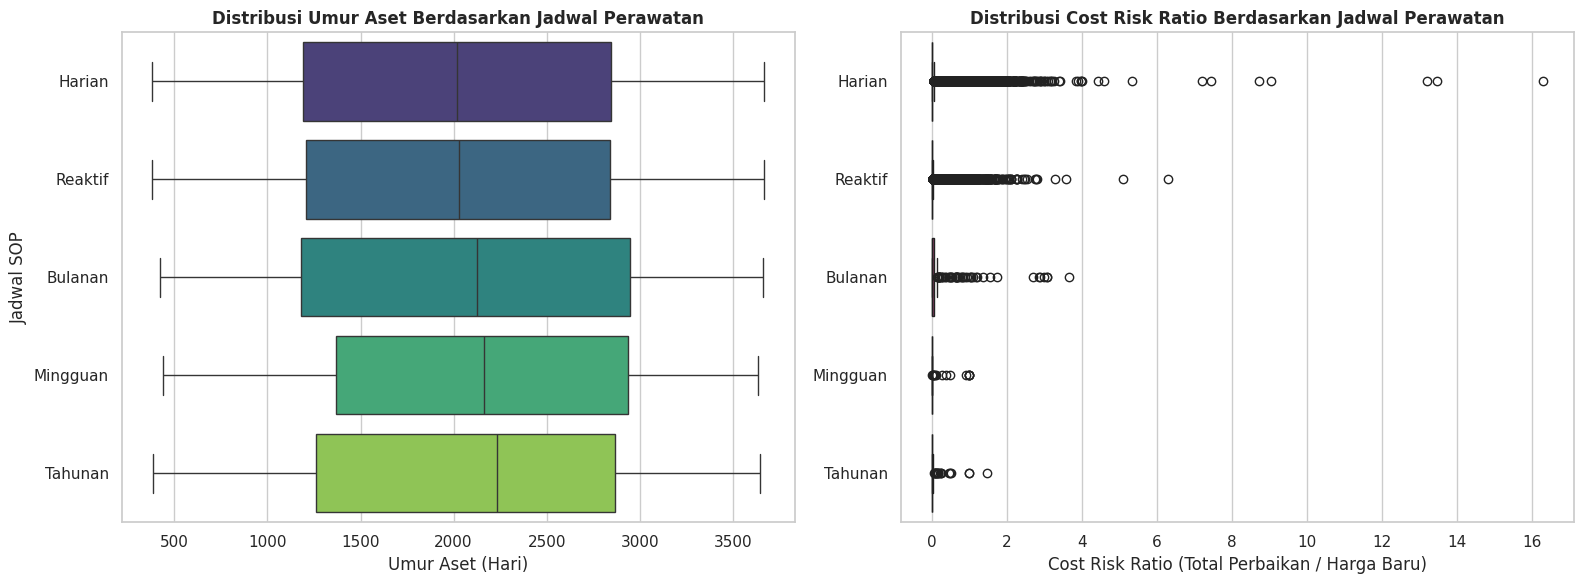

In [93]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(1, 2, figsize=(16, 6))

sns.boxplot(data=abt, y='Target_Frekuensi', x='Umur_Aset_Hari', ax=ax[0], palette='viridis')
ax[0].set_title('Distribusi Umur Aset Berdasarkan Jadwal Perawatan', fontweight='bold')
ax[0].set_xlabel('Umur Aset (Hari)')
ax[0].set_ylabel('Jadwal SOP')

sns.boxplot(data=abt, y='Target_Frekuensi', x='Cost_Risk_Ratio', ax=ax[1], palette='magma')
ax[1].set_title('Distribusi Cost Risk Ratio Berdasarkan Jadwal Perawatan', fontweight='bold')
ax[1].set_xlabel('Cost Risk Ratio (Total Perbaikan / Harga Baru)')
ax[1].set_ylabel('') 

plt.tight_layout()
plt.show()

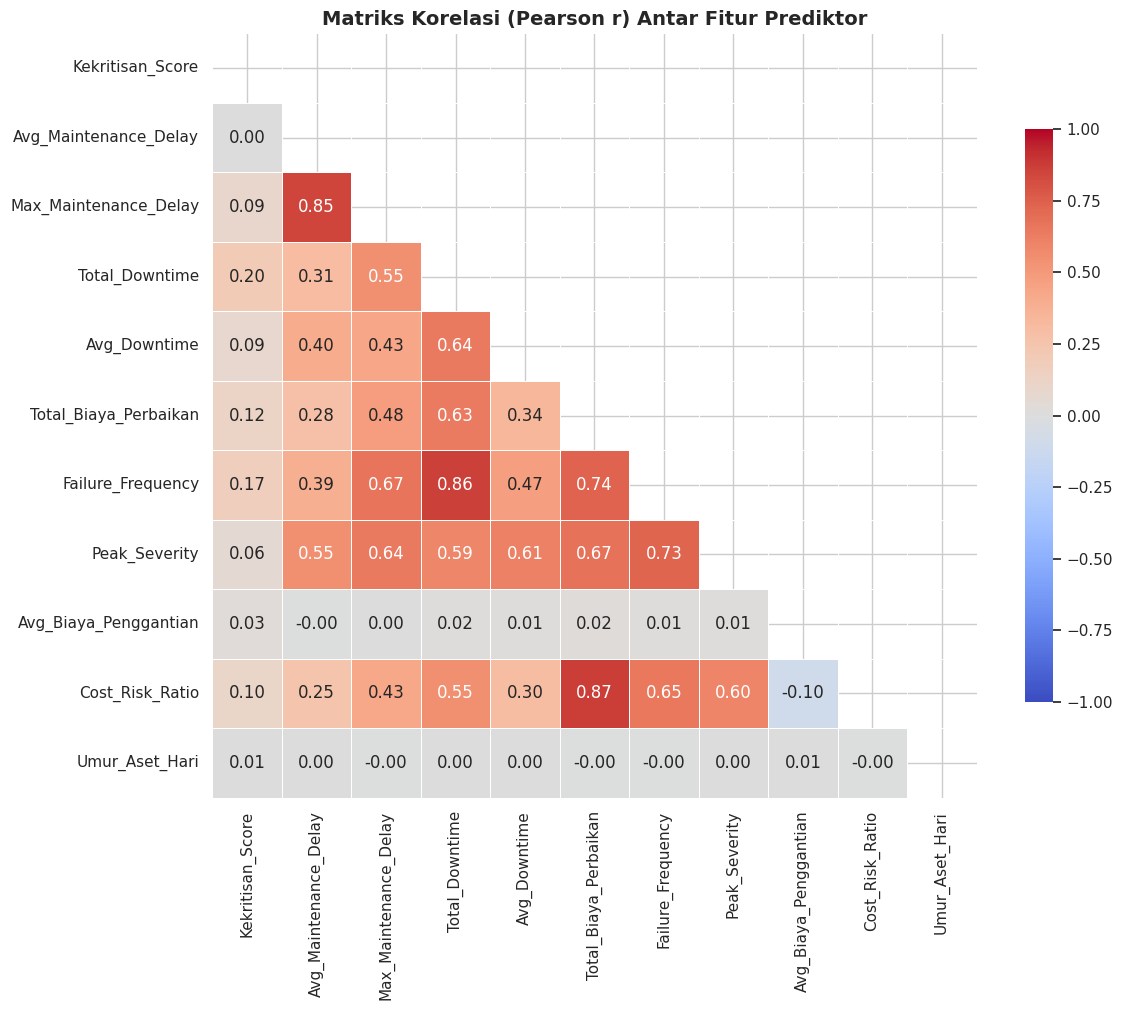

In [94]:
import numpy as np

numerics = ['int16', 'int32', 'int64', 'float16', 'float32', 'float64']
df_numeric = abt.select_dtypes(include=numerics).copy()

if 'ID Aset' in df_numeric.columns:
    df_numeric.drop(columns=['ID Aset'], inplace=True)

corr_matrix = df_numeric.corr(method='pearson')

plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap='coolwarm', 
            vmin=-1, vmax=1, square=True, linewidths=.5, cbar_kws={"shrink": .75})

plt.title('Matriks Korelasi (Pearson r) Antar Fitur Prediktor', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

In [95]:
from sklearn.preprocessing import LabelEncoder

cols_to_drop = ['ID Aset', 'Kategori', 'Sub Kategori', 'Tipe', 'Tanggal Instalasi']
X = abt.drop(columns=cols_to_drop + ['Target_Frekuensi']).copy()

le = LabelEncoder()
y = le.fit_transform(abt['Target_Frekuensi'])

print("Dimensi X (Fitur):", X.shape)
print("Dimensi y (Target):", y.shape)

dict(zip(le.classes_, le.transform(le.classes_)))

Dimensi X (Fitur): (48344, 11)
Dimensi y (Target): (48344,)


{'Bulanan': np.int64(0),
 'Harian': np.int64(1),
 'Mingguan': np.int64(2),
 'Reaktif': np.int64(3),
 'Tahunan': np.int64(4)}

# Data Augmentation

In [96]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
import pandas as pd

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

(X_train.shape, X_train_sm.shape)

((38675, 11), (140755, 11))

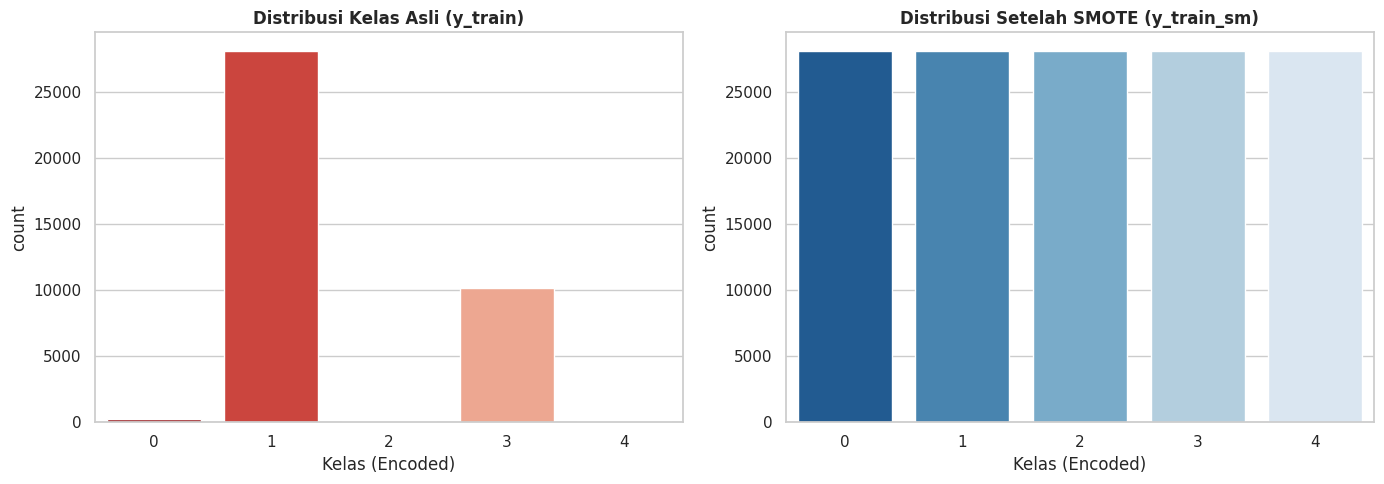

1    28151
4    28151
3    28151
0    28151
2    28151
Name: count, dtype: int64

In [97]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(x=y_train, ax=ax[0], palette='Reds_r')
ax[0].set_title('Distribusi Kelas Asli (y_train)', fontweight='bold')
ax[0].set_xlabel('Kelas (Encoded)')

sns.countplot(x=y_train_sm, ax=ax[1], palette='Blues_r')
ax[1].set_title('Distribusi Setelah SMOTE (y_train_sm)', fontweight='bold')
ax[1].set_xlabel('Kelas (Encoded)')

plt.tight_layout()
plt.show()

pd.Series(y_train_sm).value_counts()

# HyperParameter dan Modelling

In [98]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV

rf_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

xgb_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 6, 10],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.8, 1.0]
}

In [99]:
rf_base = RandomForestClassifier(random_state=42, n_jobs=-1)

rf_random = RandomizedSearchCV(
    estimator=rf_base, 
    param_distributions=rf_param_grid, 
    n_iter=5, 
    cv=3, 
    random_state=42, 
    n_jobs=-1, 
    scoring='accuracy'
)

rf_random.fit(X_train_sm, y_train_sm)

rf_best_params = rf_random.best_params_
rf_best_score = rf_random.best_score_

(rf_best_params, rf_best_score)

({'n_estimators': 300,
  'min_samples_split': 2,
  'min_samples_leaf': 1,
  'max_depth': None},
 np.float64(0.968548359991408))

In [100]:
xgb_base = XGBClassifier(random_state=42, n_jobs=-1, objective='multi:softmax', num_class=5)

xgb_random = RandomizedSearchCV(
    estimator=xgb_base, 
    param_distributions=xgb_param_grid, 
    n_iter=5, 
    cv=3, 
    random_state=42, 
    n_jobs=-1, 
    scoring='accuracy'
)

xgb_random.fit(X_train_sm, y_train_sm)

xgb_best_params = xgb_random.best_params_
xgb_best_score = xgb_random.best_score_

(xgb_best_params, xgb_best_score)

({'subsample': 0.8, 'n_estimators': 200, 'max_depth': 6, 'learning_rate': 0.2},
 np.float64(0.9870840252779046))

In [101]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

rf_final = RandomForestClassifier(
    n_estimators=300,
    min_samples_split=2,
    min_samples_leaf=1,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

xgb_final = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.2,
    subsample=0.8,
    random_state=42,
    n_jobs=-1,
    objective='multi:softmax',
    num_class=5
)

rf_final.fit(X_train_sm, y_train_sm)
xgb_final.fit(X_train_sm, y_train_sm)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.2, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=200,
              n_jobs=-1, num_class=5, ...)

In [102]:
from sklearn.metrics import classification_report
import pandas as pd

rf_pred = rf_final.predict(X_test)
rf_report = classification_report(y_test, rf_pred, target_names=le.classes_, output_dict=True)

pd.DataFrame(rf_report).transpose()

,precision,recall,f1-score,support
Bulanan,0.812500,0.750000,0.780000,52.000000
Harian,0.940380,0.956948,0.948592,7038.000000
Mingguan,0.135802,0.733333,0.229167,15.000000
Reaktif,0.891102,0.826651,0.857667,2544.000000
Tahunan,0.777778,0.700000,0.736842,20.000000
accuracy,0.920674,0.920674,0.920674,0.920674
macro avg,0.711512,0.793386,0.710454,9669.000000
weighted avg,0.925142,0.920674,0.922208,9669.000000


In [103]:
xgb_pred = xgb_final.predict(X_test)
xgb_report = classification_report(y_test, xgb_pred, target_names=le.classes_, output_dict=True)

pd.DataFrame(xgb_report).transpose()

,precision,recall,f1-score,support
Bulanan,0.339130,0.750000,0.467066,52.000000
Harian,0.978514,0.944729,0.961324,7038.000000
Mingguan,0.100775,0.866667,0.180556,15.000000
Reaktif,0.922926,0.927280,0.925098,2544.000000
Tahunan,0.202703,0.750000,0.319149,20.000000
accuracy,0.938567,0.938567,0.938567,0.938567
macro avg,0.508810,0.847735,0.570639,9669.000000
weighted avg,0.957483,0.938567,0.946595,9669.000000


In [104]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import pandas as pd

rf_proba = rf_final.predict_proba(X_test)
xgb_proba = xgb_final.predict_proba(X_test)

metrics_data = {
    'Accuracy': [
        accuracy_score(y_test, rf_pred), 
        accuracy_score(y_test, xgb_pred)
    ],
    'Precision (Macro)': [
        precision_score(y_test, rf_pred, average='macro', zero_division=0), 
        precision_score(y_test, xgb_pred, average='macro', zero_division=0)
    ],
    'Recall (Macro)': [
        recall_score(y_test, rf_pred, average='macro', zero_division=0), 
        recall_score(y_test, xgb_pred, average='macro', zero_division=0)
    ],
    'F1-Score (Macro)': [
        f1_score(y_test, rf_pred, average='macro', zero_division=0), 
        f1_score(y_test, xgb_pred, average='macro', zero_division=0)
    ],
    'ROC-AUC (OVR)': [
        roc_auc_score(y_test, rf_proba, multi_class='ovr', average='macro'), 
        roc_auc_score(y_test, xgb_proba, multi_class='ovr', average='macro')
    ]
}

df_metrics_comparison = pd.DataFrame(metrics_data, index=['Random Forest', 'XGBoost'])
df_metrics_comparison

,Accuracy,Precision (Macro),Recall (Macro),F1-Score (Macro),ROC-AUC (OVR)
Random Forest,0.920674,0.711512,0.793386,0.710454,0.981717
XGBoost,0.938567,0.508810,0.847735,0.570639,0.989730


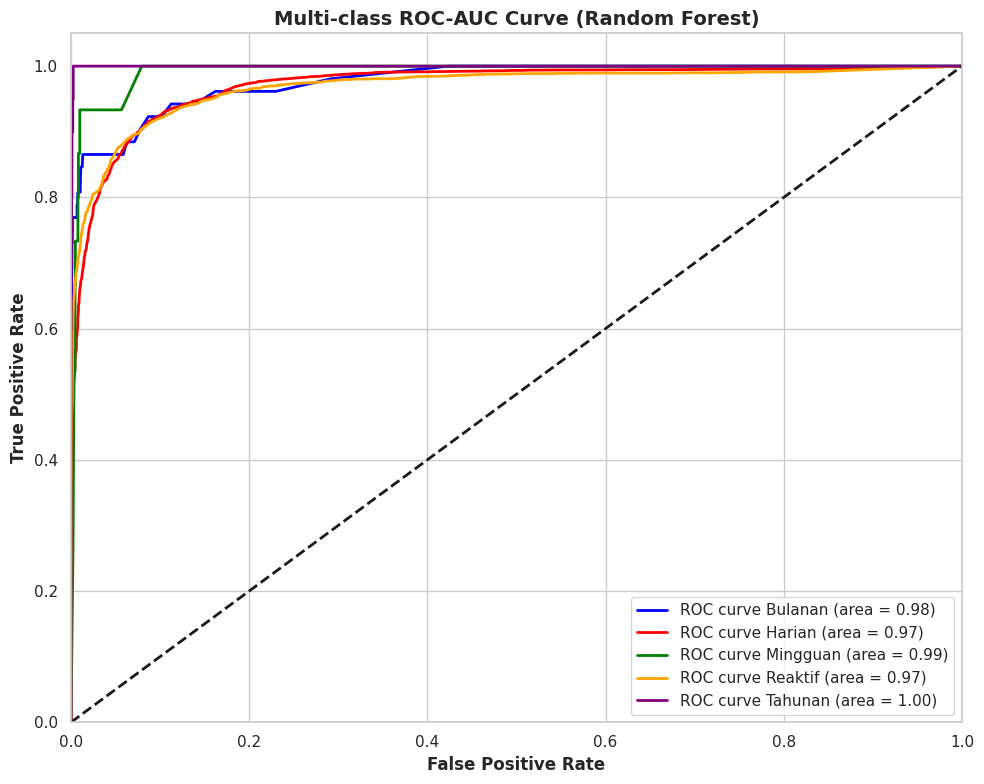

In [105]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import numpy as np

y_test_bin = label_binarize(y_test, classes=np.unique(y_test))
n_classes = y_test_bin.shape[1]

fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], rf_proba[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(10, 8))
colors = ['blue', 'red', 'green', 'orange', 'purple']

for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'ROC curve {le.classes_[i]} (area = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontweight='bold')
plt.ylabel('True Positive Rate', fontweight='bold')
plt.title('Multi-class ROC-AUC Curve (Random Forest)', fontweight='bold', fontsize=14)
plt.legend(loc="lower right")
plt.tight_layout()

plt.show()

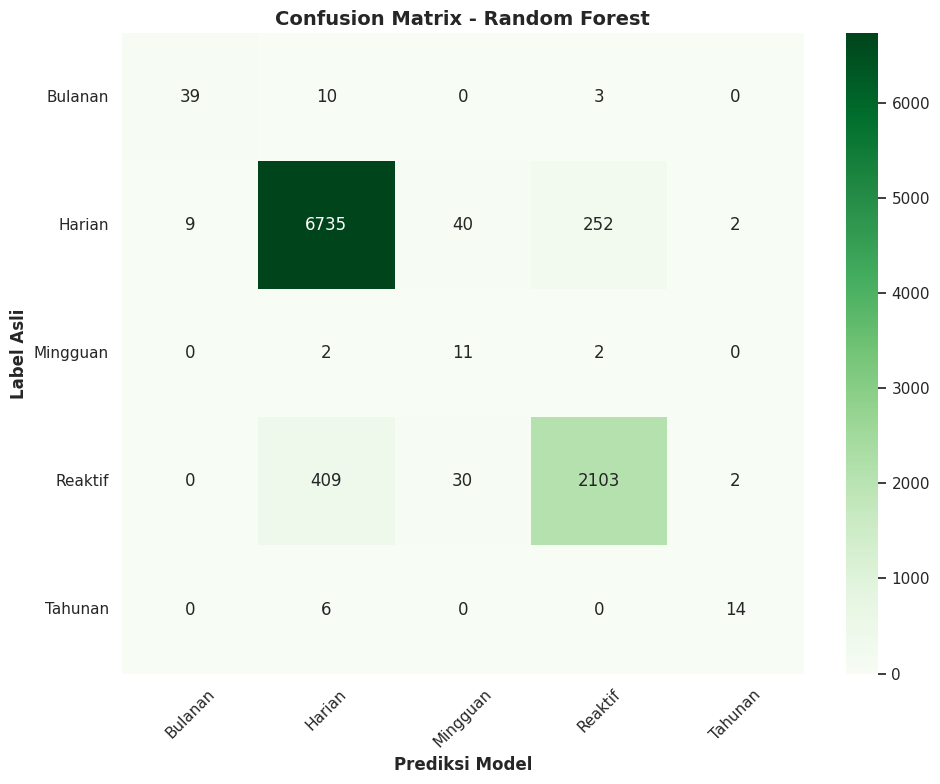

In [106]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm_rf = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', 
            xticklabels=le.classes_, 
            yticklabels=le.classes_,
            annot_kws={"size": 12})

plt.title('Confusion Matrix - Random Forest', fontweight='bold', fontsize=14)
plt.xlabel('Prediksi Model', fontsize=12, fontweight='bold')
plt.ylabel('Label Asli', fontsize=12, fontweight='bold')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()

plt.show()

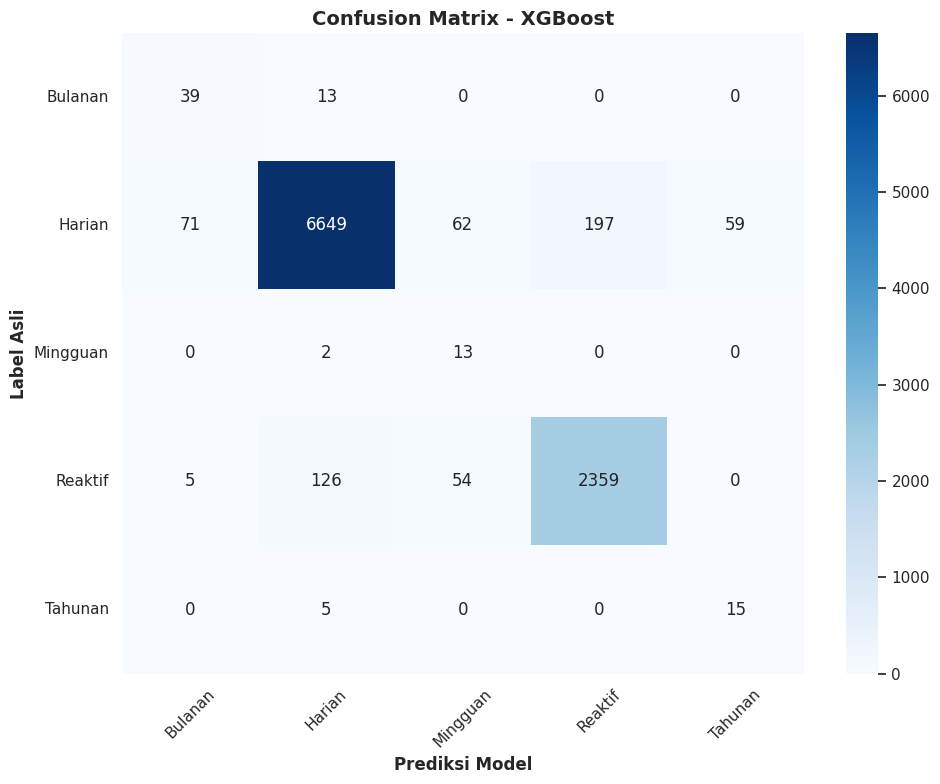

In [107]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, xgb_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=le.classes_, 
            yticklabels=le.classes_,
            annot_kws={"size": 12})

plt.title('Confusion Matrix - XGBoost', fontweight='bold', fontsize=14)
plt.xlabel('Prediksi Model', fontsize=12, fontweight='bold')
plt.ylabel('Label Asli', fontsize=12, fontweight='bold')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()

plt.show()

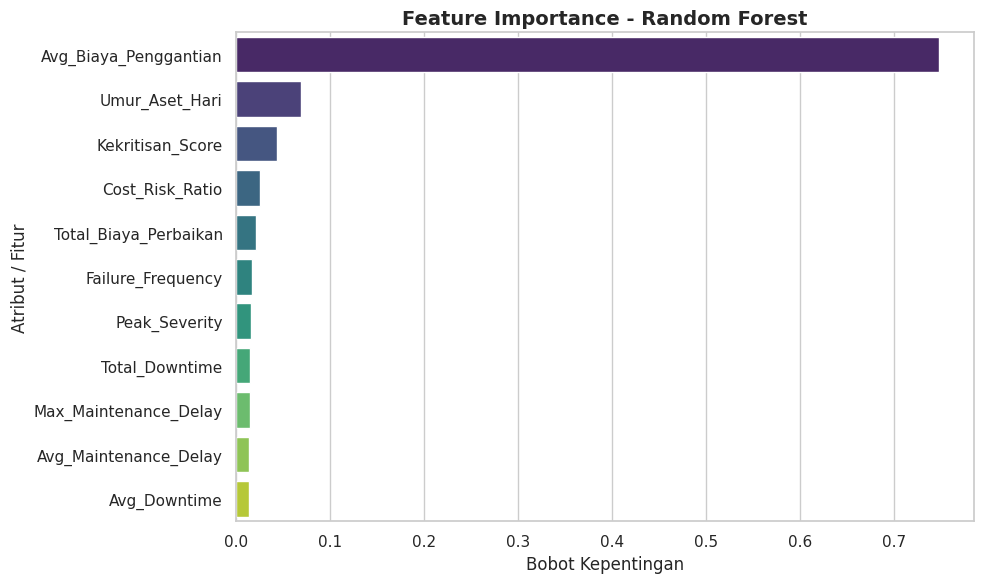

In [108]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

importances = rf_final.feature_importances_

df_importance = pd.DataFrame({
    'Fitur': X.columns,
    'Tingkat_Kepentingan': importances
}).sort_values(by='Tingkat_Kepentingan', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Tingkat_Kepentingan', y='Fitur', data=df_importance, palette='viridis')

plt.title('Feature Importance - Random Forest', fontweight='bold', fontsize=14)
plt.xlabel('Bobot Kepentingan', fontsize=12)
plt.ylabel('Atribut / Fitur', fontsize=12)
plt.tight_layout()

plt.show()

# Deep Learning

In [109]:
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.utils import to_categorical

scaler = StandardScaler()
X_train_dl = scaler.fit_transform(X_train_sm)
X_test_dl = scaler.transform(X_test)

y_train_dl = to_categorical(y_train_sm, num_classes=5)
y_test_dl = to_categorical(y_test, num_classes=5)

In [110]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam

model_dl = Sequential([
    Dense(128, activation='relu', input_shape=(X_train_dl.shape[1],)),
    BatchNormalization(),
    Dropout(0.3),
    
    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    
    Dense(32, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),
    
    Dense(5, activation='softmax')
])

model_dl.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

I0000 00:00:1779195316.808176      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13349 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1779195316.814394      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [111]:
history = model_dl.fit(
    X_train_dl, y_train_dl,
    epochs=50,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)

Epoch 1/50


I0000 00:00:1779195320.484160     483 service.cc:152] XLA service 0x26546c90 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1779195320.484194     483 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1779195320.484198     483 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1779195320.990303     483 cuda_dnn.cc:529] Loaded cuDNN version 91002


  66/1760 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.2868 - loss: 1.9424

I0000 00:00:1779195323.707704     483 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1760/1760 ━━━━━━━━━━━━━━━━━━━━ 14s 5ms/step - accuracy: 0.4872 - loss: 1.3025 - val_accuracy: 0.0016 - val_loss: 5.5784
Epoch 2/50
1760/1760 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.6738 - loss: 0.8243 - val_accuracy: 0.0016 - val_loss: 5.3198
Epoch 3/50
1760/1760 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7172 - loss: 0.7110 - val_accuracy: 0.0019 - val_loss: 5.2255
Epoch 4/50
1760/1760 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7397 - loss: 0.6550 - val_accuracy: 0.0020 - val_loss: 5.4491
Epoch 5/50
1760/1760 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7528 - loss: 0.6159 - val_accuracy: 0.0022 - val_loss: 4.5024
Epoch 6/50
1760/1760 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7610 - loss: 0.5990 - val_accuracy: 0.0020 - val_loss: 4.8376
Epoch 7/50
1760/1760 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7725 - loss: 0.5719 - val_accuracy: 0.0020 - val_loss: 4.9322
Epoch 8/50
1760/1760 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7786 - loss: 0.5558 - val_accura

In [112]:
loss, dl_accuracy = model_dl.evaluate(X_test_dl, y_test_dl, verbose=0)

import numpy as np
from sklearn.metrics import classification_report

y_pred_dl_probs = model_dl.predict(X_test_dl)
y_pred_dl = np.argmax(y_pred_dl_probs, axis=1)

print(f"Accuracy Deep Learning: {dl_accuracy:.4f}")
print(classification_report(y_test, y_pred_dl, target_names=le.classes_))

303/303 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Accuracy Deep Learning: 0.7112
              precision    recall  f1-score   support

     Bulanan       0.06      0.81      0.10        52
      Harian       0.86      0.77      0.82      7038
    Mingguan       0.06      0.80      0.11        15
     Reaktif       0.57      0.55      0.56      2544
     Tahunan       0.00      0.00      0.00        20

    accuracy                           0.71      9669
   macro avg       0.31      0.59      0.32      9669
weighted avg       0.78      0.71      0.74      9669



# Export Model

In [113]:
import joblib

joblib.dump(rf_final, 'prism_rf_model.pkl')
joblib.dump(le, 'prism_label_encoder.pkl')
joblib.dump(list(X.columns), 'prism_features.pkl')

['prism_features.pkl']